# **Objectif** :
**Prédire ou comprendre le churn (départ client)**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from google.colab import drive\

drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
df=pd.read_excel('/content/drive/MyDrive/Formation_IA_ForceN/Telco_customer_churn.xlsx')
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


# **Liste des variables et leurs significations**

**1. Identification du client**

**CustomerID**: identifiant unique du client
Count : compteur (souvent = 1 pour chaque ligne, peu utile)

**2. Informations géographiques**

**Country**: pays du client

**State**: état / région (ex : California)

**City** : ville

**Zip Code**: code postal

**Lat Long** : coordonnées géographiques (latitude, longitude combinées)

**Latitude** : latitude

**Longitude**: longitude

**3. Informations démographiques**

**Gender** : sexe (Male / Female)

**Senior Citizen**: personne âgée (1 = oui, 0 = non)

**Partner :** a un partenaire (Yes / No)

**Dependents**: a des personnes à charge (Yes / No)

*Utilité : comprendre quels profils quittent le service*

**4. Services souscrits**

**Phone Service**: a un service téléphonique

**Multiple Lines**: plusieurs lignes téléphoniques

**Internet**

**Internet Service**: type d’internet (DSL, Fiber optic, None)

**Online Security** : sécurité en ligne

**Online Backup** : sauvegarde en ligne

**Device Protection** : protection des appareils

**Tech Support**: assistance technique

**Streaming TV**: TV en streaming

**Streaming Movies** : films en streaming

*Utilité : voir quels services fidélisent ou font fuir*

**5. Informations sur le contrat**

**Contract** : type de contrat

-Month-to-month (mensuel)

-One year

-Two year

**Paperless Billing**: facture électronique (Yes / No)

**Payment Method**: méthode de paiement

-Electronic check

-Mailed check

-Bank transfer

-Credit card

*Très important pour analyser le churn*

**6. Données financières**

**Monthly Charges**: montant payé par mois

**Total Charges**: montant total payé depuis le début

*Permet de voir*:

clients chers

clients rentables

**7. Variables liées au churn (OBJECTIF)**

**Churn Label :**

 Yes = client parti

 No = client resté

**Churn Value** :

1 = churn

0 = pas churn

**Churn Score**: score de probabilité de départ (souvent calculé par un modèle)

**Churn Reason** : raison du départ

Exemples :

-Competitor made better offer

-Moved

-Price too high

**8. Valeur client**

CLTV (Customer Lifetime Value) : valeur totale estimée du client pour
l’entreprise

*Très important pour le business* :
savoir quels clients sont les plus rentables

In [ ]:
df['Phone Service']

,Phone Service
0,Yes
1,Yes
2,Yes
3,Yes
4,Yes
...,...
7038,Yes
7039,Yes
7040,Yes
7041,No


In [ ]:
df['Internet Service']

,Internet Service
0,DSL
1,Fiber optic
2,Fiber optic
3,Fiber optic
4,Fiber optic
...,...
7038,No
7039,DSL
7040,Fiber optic
7041,DSL


In [ ]:
df['Tenure Months']

,Tenure Months
0,2
1,2
2,8
3,28
4,49
...,...
7038,72
7039,24
7040,72
7041,11


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df['CLTV']

,CLTV
0,3239
1,2701
2,5372
3,5003
4,5340
...,...
7038,5306
7039,2140
7040,5560
7041,2793


In [ ]:
l=['CustomerID','Count','Country','State','City','Zip Code','Lat Long','Latitude','Longitude','Churn Label','Churn Score','Churn Reason','CLTV']

In [ ]:
df1=df.drop(columns=l)
df1

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,0
7039,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,0
7040,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,0
7041,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0


In [ ]:
df1['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.5
3,3046.05
4,5036.3
...,...
7038,1419.4
7039,1990.5
7040,7362.9
7041,346.45


# **Corriger le type de Total Charges**

In [ ]:
df1['Total Charges'].dtypes

dtype('O')

In [ ]:
df1['Total Charges'] = pd.to_numeric(df1['Total Charges'], errors='coerce')

In [ ]:
df1['Total Charges']=df1['Total Charges'].astype(float)

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [ ]:
df1.isnull().sum()

,0
Gender,0
Senior Citizen,0
Partner,0
Dependents,0
Tenure Months,0
Phone Service,0
Multiple Lines,0
Internet Service,0
Online Security,0
Online Backup,0


In [ ]:
df1.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
7038,False
7039,False
7040,False
7041,False


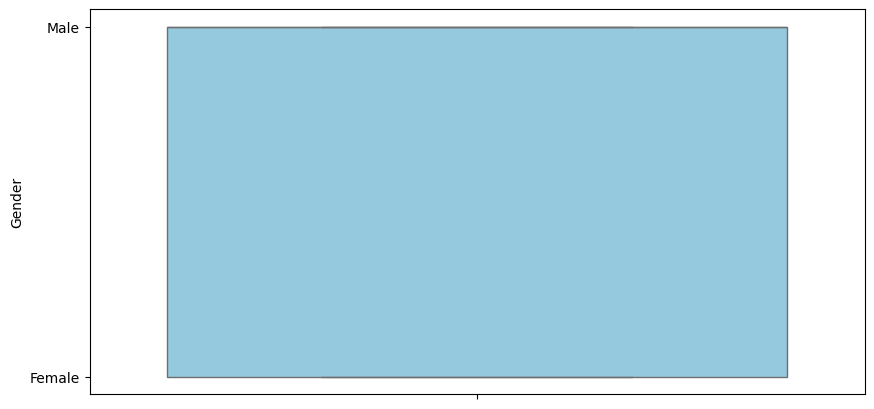

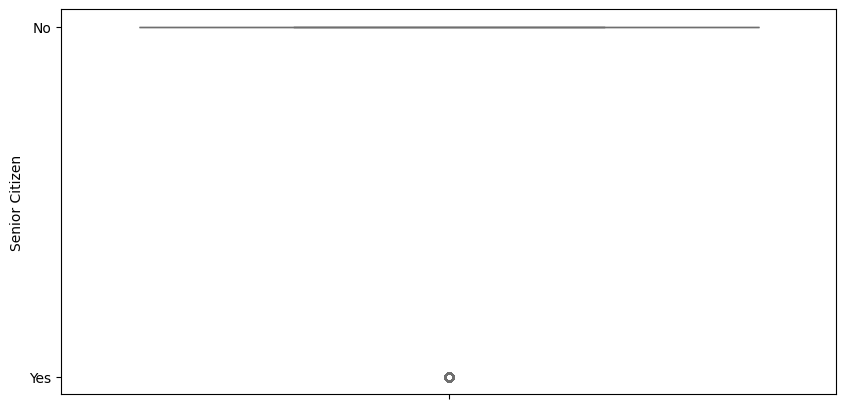

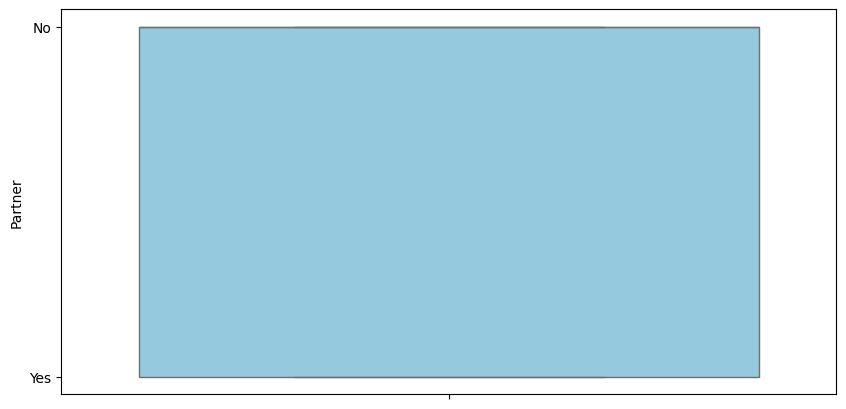

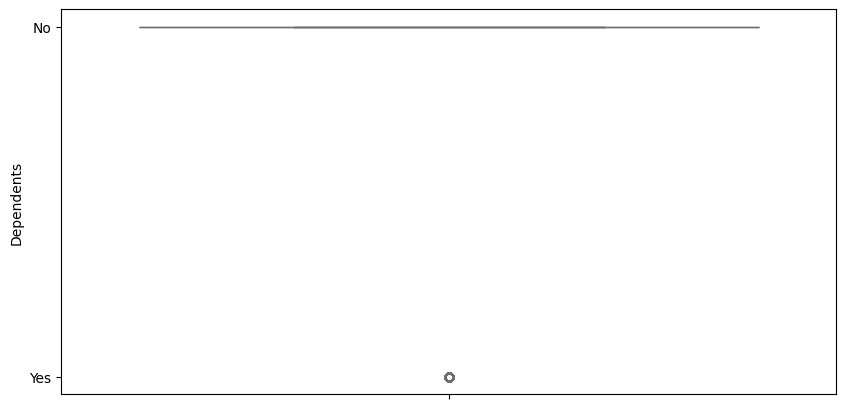

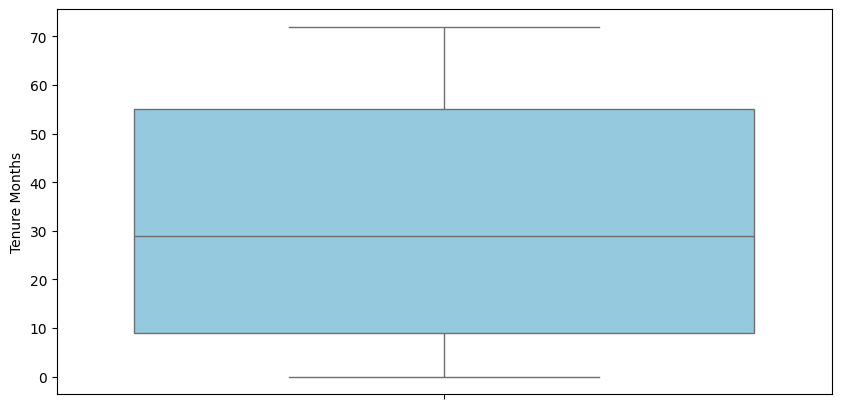

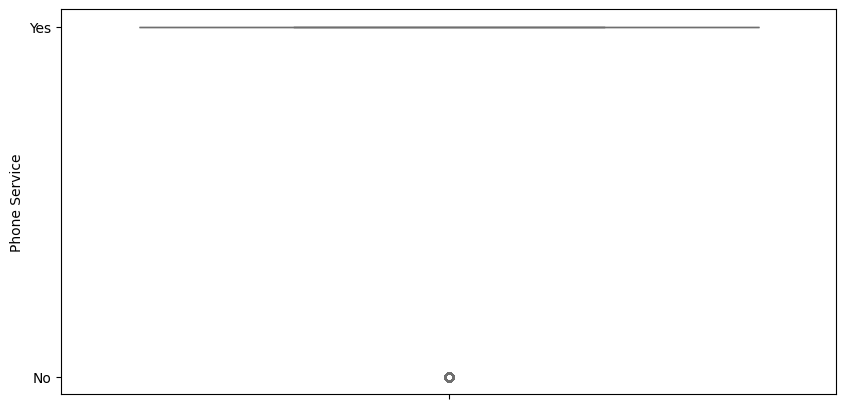

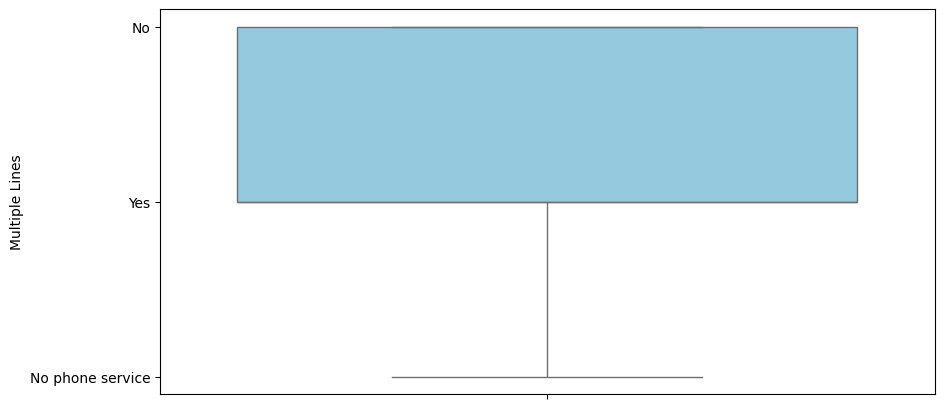

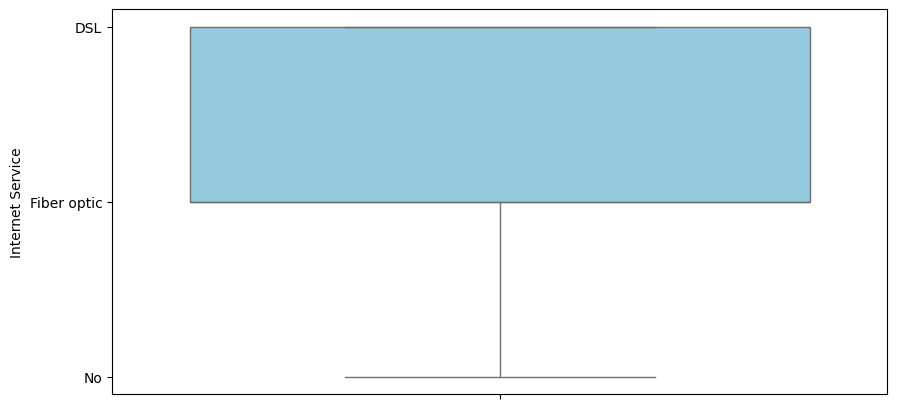

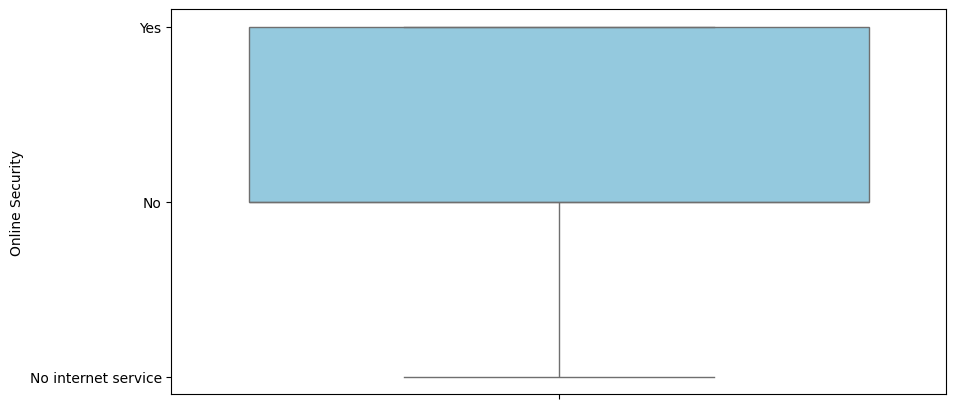

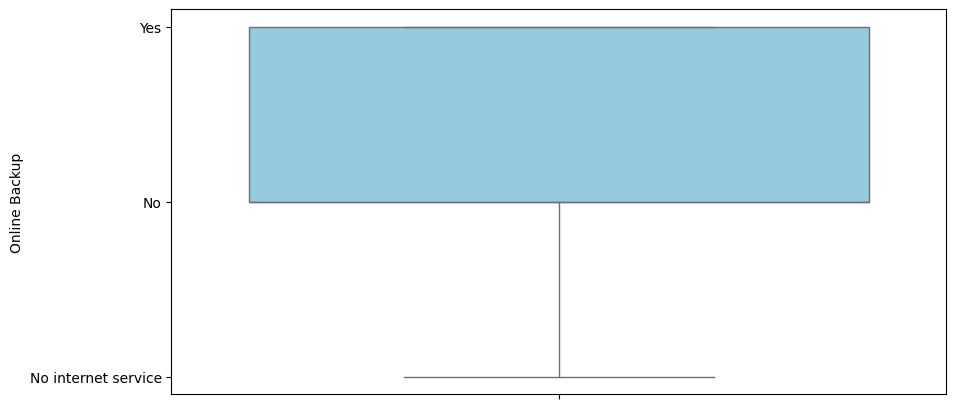

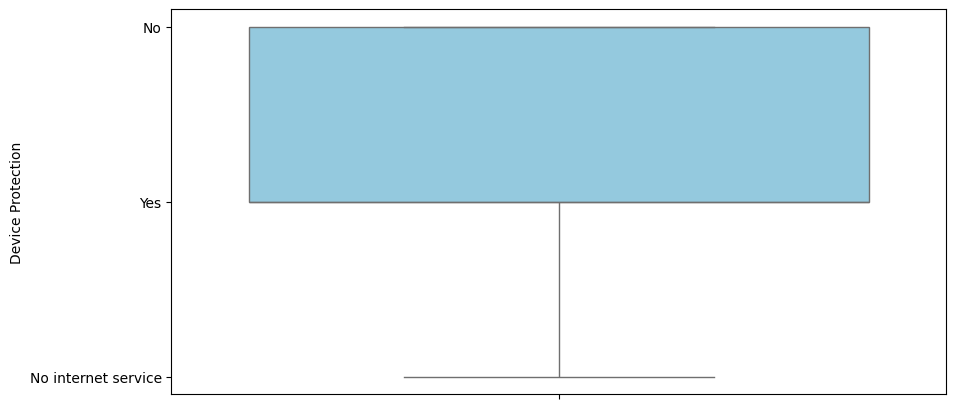

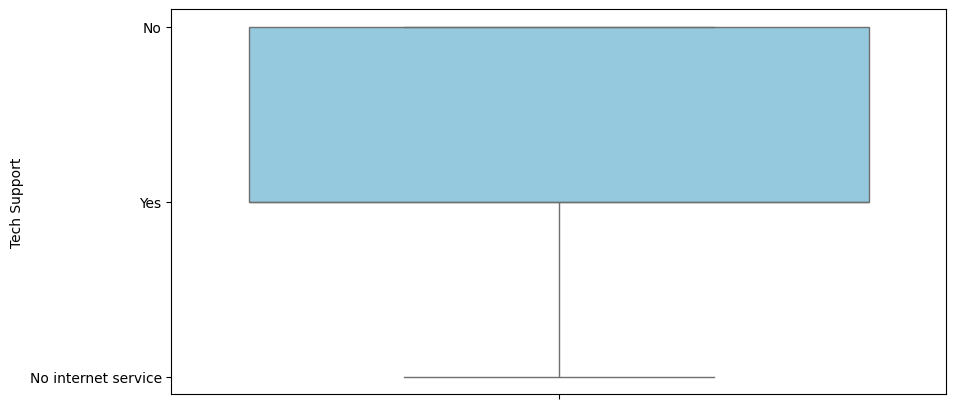

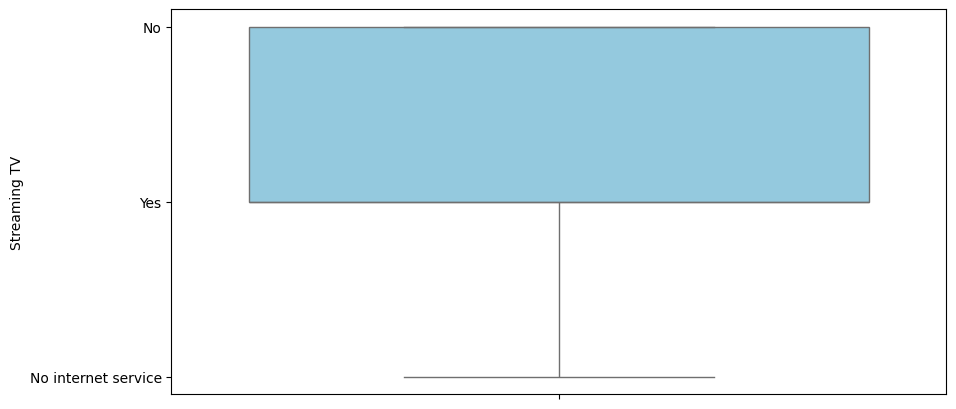

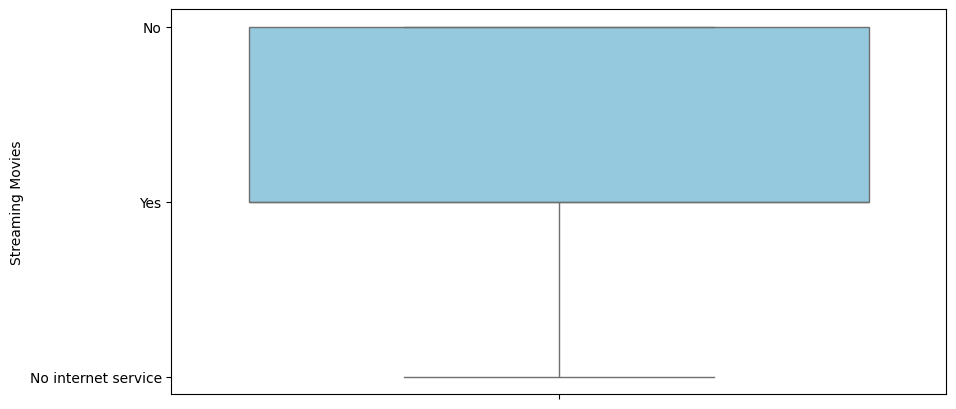

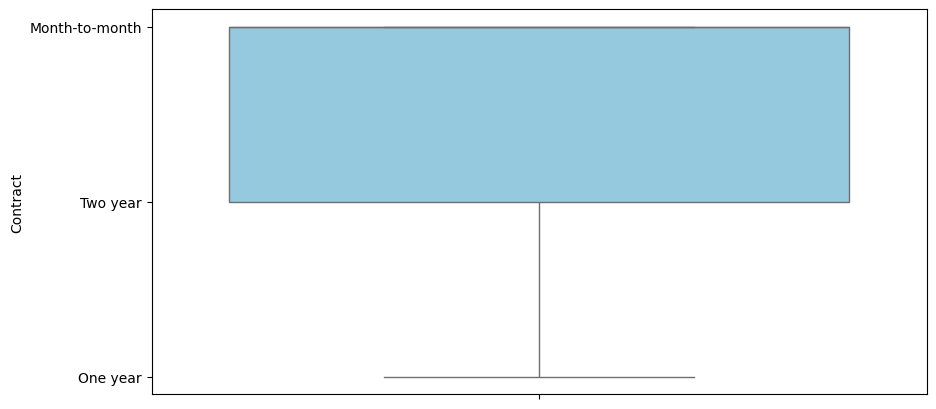

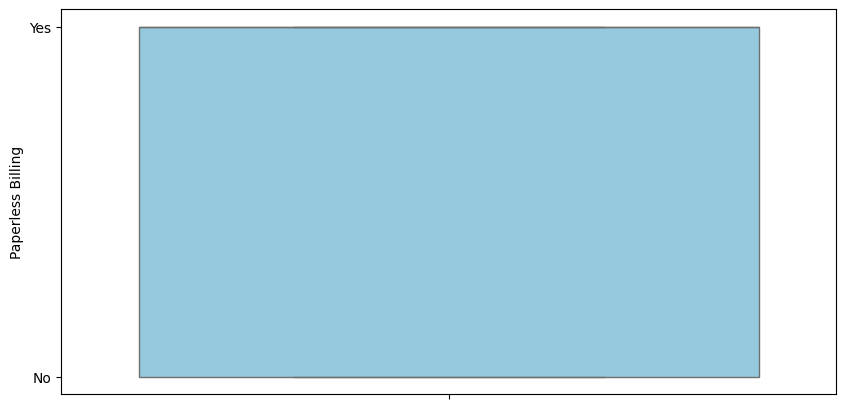

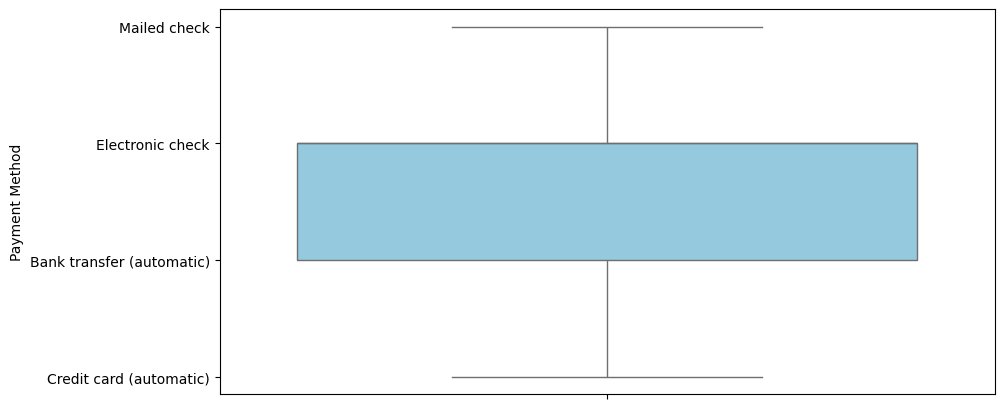

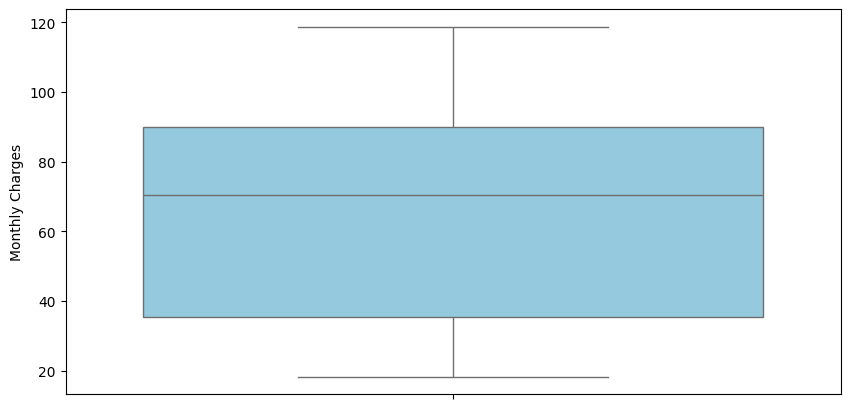

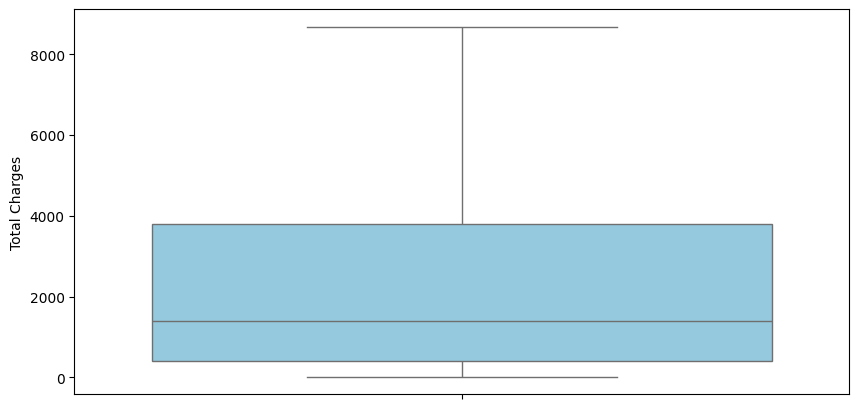

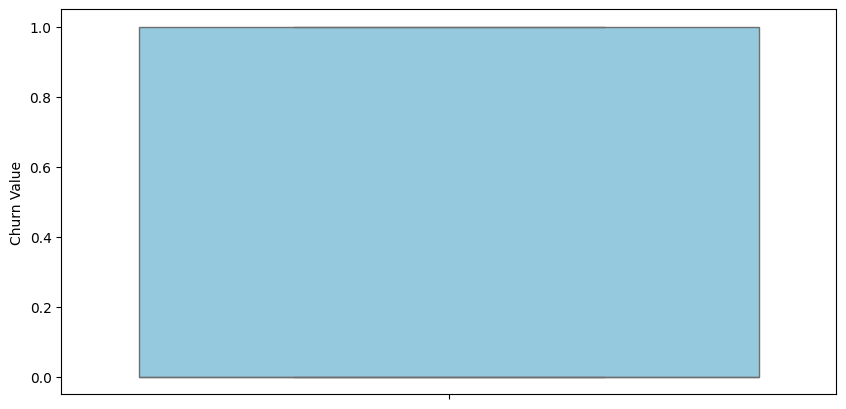

In [ ]:
for i in df1.columns:
  plt.figure(figsize=(10,5))
  sns.boxplot(df1[i],color='skyblue')
  plt.show()

In [ ]:
col_Categories=df1.select_dtypes(include='object').columns
col_Categories

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method'],
      dtype='object')

In [ ]:
df1_Encoding=pd.get_dummies(df1,columns=col_Categories,drop_first=True)
df1_Encoding = df1_Encoding.fillna(df1_Encoding.mean())
df1_Encoding

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,72,21.15,1419.40,0,False,False,False,False,True,False,...,True,False,True,False,False,True,True,False,False,False
7039,24,84.80,1990.50,0,True,False,True,True,True,False,...,False,True,False,True,True,False,True,False,False,True
7040,72,103.20,7362.90,0,False,False,True,True,True,False,...,False,True,False,True,True,False,True,True,False,False
7041,11,29.60,346.45,0,False,False,True,True,False,True,...,False,False,False,False,False,False,True,False,True,False


In [ ]:
X=df1_Encoding.drop(columns='Churn Value')
y=df1_Encoding['Churn Value']

# **Random Forest**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
#separation des variable
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
#Creation du model
rf=RandomForestClassifier(n_estimators=100, max_depth=5)
#Entrainement du model
rf.fit(X_train,y_train)
#prediction
y1_pred=rf.predict(X_test)


In [ ]:
y1_pred

array([1, 0, 0, ..., 1, 0, 0])

In [ ]:
from sklearn.metrics import accuracy_score
# Évaluation
print("Accuracy:", accuracy_score(y_test, y1_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y1_pred))
print("Rpport de classification:\n", classification_report(y_test, y1_pred))

Accuracy: 0.7913413768630234
Confusion Matrix:
 [[936  73]
 [221 179]]
Rpport de classification:
               precision    recall  f1-score   support

           0       0.81      0.93      0.86      1009
           1       0.71      0.45      0.55       400

    accuracy                           0.79      1409
   macro avg       0.76      0.69      0.71      1409
weighted avg       0.78      0.79      0.77      1409



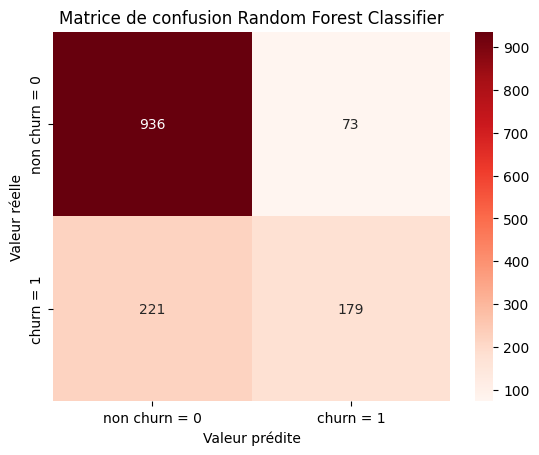

In [ ]:
cm1=confusion_matrix(y_test,y1_pred)
nom_classe=['non churn = 0','churn = 1']
sns.heatmap(cm1,cmap='Reds',annot=True,fmt='d',
            xticklabels=nom_classe,
            yticklabels=nom_classe,

            )
plt.xlabel('Valeur prédite')
plt.ylabel('Valeur réelle')
plt.title('Matrice de confusion Random Forest Classifier')
plt.show()

# **Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

#separation des variable
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
# definition du model
lr=LogisticRegression()
# Entrainement du model
lr.fit(X_train,y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y2_pred=lr.predict(X_test)

In [ ]:
y2_pred

array([1, 0, 0, ..., 1, 0, 1])

In [ ]:
# Évaluation
print("Accuracy:", accuracy_score(y_test, y2_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test,y2_pred))

Accuracy: 0.7984386089425124
Confusion Matrix:
 [[906 103]
 [181 219]]


In [ ]:
cm=confusion_matrix(y_test,y2_pred)

In [ ]:
cm

array([[906, 103],
       [181, 219]])

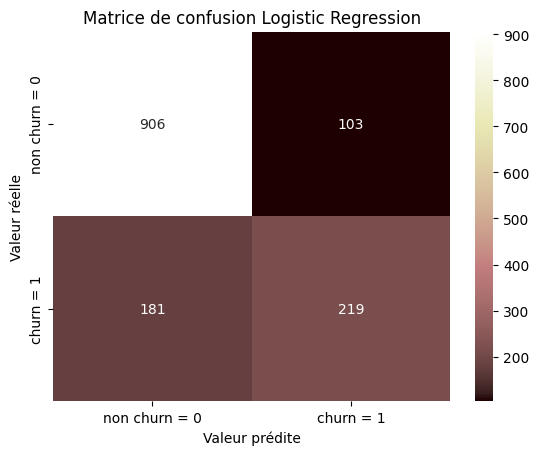

In [ ]:
cm=confusion_matrix(y_test,y2_pred)
nom_classe=['non churn = 0','churn = 1']
sns.heatmap(cm,cmap='pink',annot=True,fmt='d',
            xticklabels=nom_classe,
            yticklabels=nom_classe,

            )
plt.xlabel('Valeur prédite')
plt.ylabel('Valeur réelle')
plt.title('Matrice de confusion Logistic Regression')
plt.show()

Pour la methode RandomForest,on a une accuracy de 78,7 pourcent alors que pour le regression Logistiaue on a 79,8 pourcent de plus pour la regression logistic les FN et les FP sont moins importante que pour la methode de Random Forest alors on peut en deduire que la regression est legerement plus precise que Random

# **XGBoost Classifier**

In [ ]:
from xgboost import XGBClassifier
xbg=XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1)
xbg.fit(X_train,y_train)
y4_pred=xbg.predict(X_test)



In [ ]:
y4_pred

array([0, 0, 0, ..., 1, 0, 1])

In [ ]:
print("Accuracy:", accuracy_score(y_test, y4_pred))

Accuracy: 0.8005677785663591


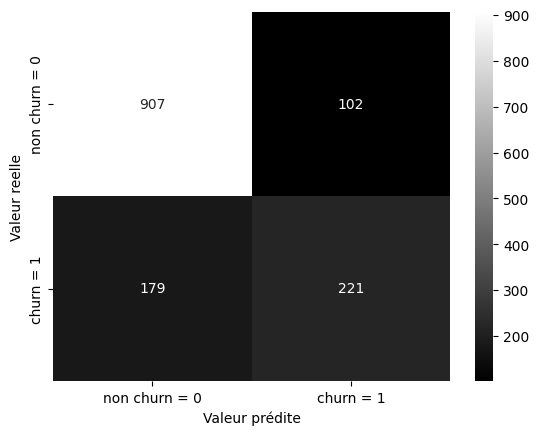

In [ ]:
cm=confusion_matrix(y_test,y4_pred)
nom_classe=['non churn = 0','churn = 1']
sns.heatmap(cm,cmap='grey',annot=True,fmt='d',
            xticklabels=nom_classe,
            yticklabels=nom_classe,

            )
plt.xlabel('Valeur prédite')
plt.ylabel('Valeur reelle')
plt.title('Matrice de confusion XGBoost Classifier')
plt.show()